In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # Lorenz96Bao2024EnSF
    # ScoreMatchingMarginal
    # ('ucdez2pm', 'EnSF'): {},  # sampling_time_step_count=100
    # ('vocphl8c', 'EnSF'): {},  # sampling_time_step_count=200
    # ('hp998gnv', 'EnSF'): {},  # sampling_time_step_count=300
    # ('5vv7pujy', 'EnSF'): {},  # sampling_time_step_count=400
    # ('0guis8gf', 'EnSF'): {},  # sampling_time_step_count=500
    # ('31btm1sj', 'EnSF'): {},  # sampling_time_step_count=600
    # FlowMatchingMarginal
    # ('j9aqtn2e', 'EnFF'): {},  # model.sampling_time_step_count=100
    # ('pn6gruvt', 'EnFF'): {},  # model.sampling_time_step_count=200
    # ('0ikqcpxf', 'EnFF'): {},  # model.sampling_time_step_count=300
    # ('h8fbk7x1', 'EnFF'): {},  # model.sampling_time_step_count=400
    # ('hjk2lkbs', 'EnFF'): {},  # model.sampling_time_step_count=500
    # ('gcet09rp', 'EnFF'): {},  # model.sampling_time_step_count=600

    # NavierStokes
    ('s5joyghi', 'EnSF RMS'): {},  # sampling_time_step_count=500
}

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('s5joyghi', 'EnSF RMS'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                        out_dir='/home/sci/ttransue/out/dafm',
                                        run_subdir='runs',
                                        prediction_filename='trajectories.parquet',
                                        device='cuda',
                                        alt_id='s5joyghi',
                                        rng_seed=2376999025,
                                        fit=True,
                                        id=50,
                                        dataset=NavierStokes(trajectory_stored_on_gpu_max_state_dimension=50,
                                                             state_dimension=49152,
                                                             model_noise_std=0.0,
                                                             observation_noise_std=0.05,
                               

In [6]:
reference_cfg = list(cfgs.values())[0]['cfg']
for v in cfgs.values():
    assert v['cfg'].dataset.id == reference_cfg.dataset.id
    
lightning.pytorch.seed_everything(reference_cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dynamics = datasets.get_dynamics_dataset(reference_cfg.dataset, reference_cfg.device)
true_state = pl.DataFrame(
    torch.cat([dynamics.data['times'], dynamics.data['true_state'][:, 0]], dim=1).numpy(),
    schema=['times', *(f'true_state_dim_{d}' for d in range(dynamics.data['true_state'][:, 0].shape[1]))],
)
del dynamics

Seed set to 2376999025


In [7]:
rmses = []
for k, v in tqdm(cfgs.items()):
    cfg = v['cfg']
    rmse = (
        pl.scan_parquet(
            cfg.run_dir/cfg.prediction_filename,
        )
        # take last X time steps when data assimilation occurred
        .sort('times')
        .gather_every(cfg.dataset.observe_every_n_time_steps, offset=1)  # offset to exclude initial condition
        .tail(50)
        
        .join(true_state.lazy(), on='times')
        .select(
            pl.lit(k[0]).alias('alt_id'),
            pl.lit(k[1]).alias('label'),
            pl.col('times'),
            pl.lit(cfg.model.sampling_time_step_count).alias('Sampling time steps'),
            pl.mean_horizontal(
                (
                    pl.col(f'predicted_state_mean_dim_{d}') - pl.col(f'true_state_dim_{d}')
                ).pow(2)
                for d in range(cfg.dataset.state_dimension)
            ).sqrt().alias('RMSE(dim)'),
        )
        .group_by('alt_id', 'label', 'Sampling time steps')
        .agg(pl.col('RMSE(dim)').mean().alias('Mean(time) RMSE(dim)'))
        .collect()
    )
    rmses.append(rmse)
rmses = pl.concat(rmses)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.74s/it]


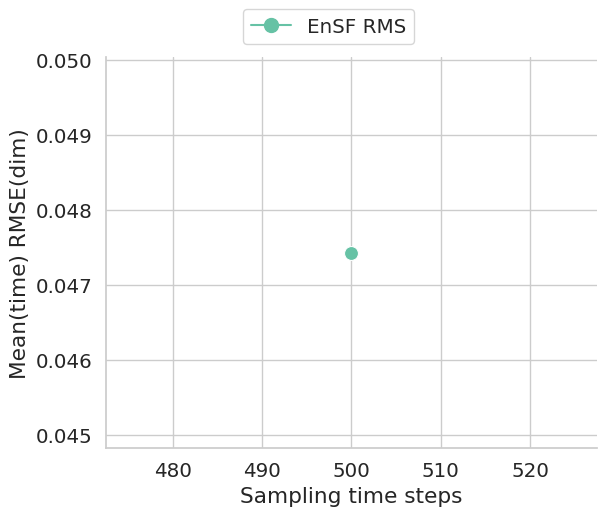

In [8]:
plot_rmse = (
    sns.relplot(
        kind='line',
        data=rmses,
        x='Sampling time steps',
        y='Mean(time) RMSE(dim)',
        hue='label',
        style='label',
        markers=True,
        markersize=10,
        aspect=1.3,
    )
) 
sns.move_legend(
    plot_rmse,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)